In [ ]:
from data.voirie import get_voirie
from data.filter import filter_impasses

G = get_voirie(place="2nd arrondissement, Paris, France")
G_propre = filter_impasses(G)


========== RÉSUMÉ ==========
Tronçons orientés (routage) : 806
Tronçons physiques         : 626

Km couverture physique     : 34.8 km
Km routage orienté         : 43.0 km

Km rues à double sens      : 8.2 km
Km rues à sens unique      : 26.6 km



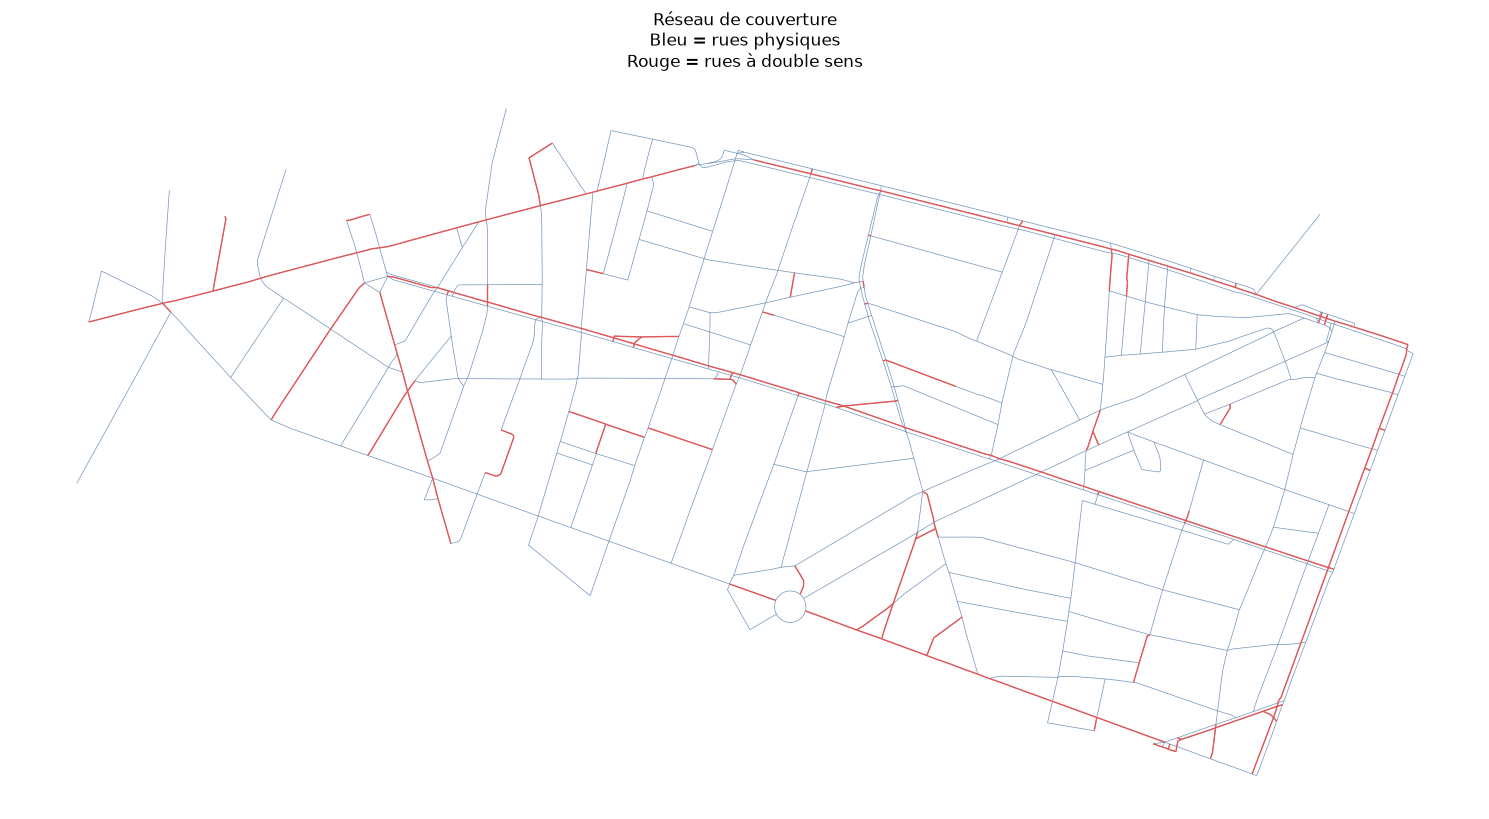

In [2]:
import osmnx as ox

# ============================================================
# 1. Extraction du graphe nettoyé
# ============================================================

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_propre)

# On travaille sur une copie tabulaire
edges = edges_gdf.reset_index().copy()

# ============================================================
# 2. Construction d'une clé physique non orientée
# ============================================================
# Une rue A->B et B->A doivent être considérées comme
# le même tronçon physique pour la couverture.

edges["pair"] = edges.apply(
    lambda r: tuple(sorted((r["u"], r["v"]))),
    axis=1
)

# ============================================================
# 3. Détection des rues bidirectionnelles
# ============================================================

pair_counts = edges.groupby("pair").size()

bidirectional_pairs = set(
    pair_counts[pair_counts > 1].index
)

edges["is_bidirectional"] = (
    edges["pair"].isin(bidirectional_pairs)
)

# ============================================================
# 4. Couche de couverture
# ============================================================
# Une seule occurrence par tronçon physique.
# On garde la première géométrie rencontrée.

coverage_edges = (
    edges
    .drop_duplicates(subset="pair")
    .copy()
)

# ============================================================
# 5. Statistiques
# ============================================================

coverage_km = (
    coverage_edges["length"].sum()
    / 1000
)

routing_km = (
    edges["length"].sum()
    / 1000
)

bidirectional_km = (
    coverage_edges.loc[
        coverage_edges["is_bidirectional"],
        "length"
    ].sum()
    / 1000
)

oneway_km = (
    coverage_edges.loc[
        ~coverage_edges["is_bidirectional"],
        "length"
    ].sum()
    / 1000
)

print()
print("========== RÉSUMÉ ==========")
print(f"Tronçons orientés (routage) : {len(edges):,}")
print(f"Tronçons physiques         : {len(coverage_edges):,}")
print()
print(f"Km couverture physique     : {coverage_km:,.1f} km")
print(f"Km routage orienté         : {routing_km:,.1f} km")
print()
print(f"Km rues à double sens      : {bidirectional_km:,.1f} km")
print(f"Km rues à sens unique      : {oneway_km:,.1f} km")
print("============================")
print()

# ============================================================
# 6. GeoDataFrames utiles pour la suite
# ============================================================

coverage_edges_gdf = coverage_edges.set_index(
    ["u", "v", "key"]
)

routing_edges_gdf = edges.set_index(
    ["u", "v", "key"]
)

# ============================================================
# 7. Exemple : visualisation
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 15))

coverage_edges_gdf.plot(
    ax=ax,
    color="#4C78A8",
    linewidth=0.5,
    alpha=0.8,
)

coverage_edges_gdf[
    coverage_edges_gdf["is_bidirectional"]
].plot(
    ax=ax,
    color="#E45756",
    linewidth=1.0,
)

ax.set_title(
    "Réseau de couverture\n"
    "Bleu = rues physiques\n"
    "Rouge = rues à double sens"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()